# TP Jour 1 — Préparer la base pour la modélisation du Jour 2

Vous devez produire une base propre et documentée.  
**Ne construisez pas encore le modèle final.**

Livrables :
1. `data_J1_clean.csv`
2. `dictionnaire_donnees.md`
3. notebook complété et commenté


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## A. Audit

In [3]:
df = pd.read_csv("C:/Users/ISITECH/Desktop/Cours IA/KIT_JOUR1/02_ETUDIANTS/data/data_J1_brut.csv")
# TODO : shape, head, info, describe, NA, doublons, cardinalités


In [4]:
df.shape

(423, 10)

In [5]:
df.head()

,machine_id,ville,type_machine,risque,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
0,M0001,Abomey-Calavi,Compresseur,Faible,NaN,3.00,6.65,13,21256.0,0
1,M0002,Cotonou,Moteur,Moyen,65.0,3.37,6.72,10,28487.0,0
2,M0003,Parakou,Pompe,Faible,77.5,NaN,7.11,15,20511.0,0
3,M0004,Abomey-Calavi,Pompe,Faible,72.5,3.12,NaN,9,31192.0,0
4,M0005,Parakou,Moteur,Moyen,74.1,4.51,6.93,13,9425.0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   machine_id       423 non-null    str    
 1   ville            423 non-null    str    
 2   type_machine     411 non-null    str    
 3   risque           423 non-null    str    
 4   temperature_C    401 non-null    float64
 5   vibration        395 non-null    float64
 6   pression_bar     403 non-null    float64
 7   age_ans          423 non-null    int64  
 8   production_jour  423 non-null    float64
 9   panne            423 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 44.0 KB


In [7]:
df.describe()

,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
count,401.000000,395.000000,403.000000,423.000000,423.000000,423.000000
mean,71.091521,3.807247,6.914243,9.033097,25138.876470,0.004728
std,8.658607,2.076071,0.552058,4.768463,9495.106460,0.068680
min,39.000000,-0.230000,5.520000,1.000000,8291.000000,0.000000
25%,66.000000,2.745000,6.495000,5.000000,19832.500000,0.000000
50%,70.600000,3.680000,6.980000,9.000000,24234.000000,0.000000
75%,76.400000,4.535000,7.290000,13.000000,29255.000000,0.000000
max,145.000000,27.474498,8.270000,17.000000,113005.631236,1.000000


In [8]:
df.isna().sum()

machine_id          0
ville               0
type_machine       12
risque              0
temperature_C      22
vibration          28
pression_bar       20
age_ans             0
production_jour     0
panne               0
dtype: int64

In [9]:
(df.isna().mean() *100).round(2)

machine_id         0.00
ville              0.00
type_machine       2.84
risque             0.00
temperature_C      5.20
vibration          6.62
pression_bar       4.73
age_ans            0.00
production_jour    0.00
panne              0.00
dtype: float64

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
418    False
419    False
420     True
421     True
422     True
Length: 423, dtype: bool

In [11]:
df.nunique(dropna=True)

machine_id         420
ville                4
type_machine         3
risque               3
temperature_C      218
vibration          279
pression_bar       193
age_ans             17
production_jour    417
panne                2
dtype: int64

### Challenge A
Construisez un tableau d'audit avec :
- type
- nombre de NA
- %
- nombre de valeurs uniques
- décision de traitement proposée


In [12]:
audit = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "nombre_NA": df.isna().sum(),
    "pourcentage_NA": (df.isna().mean() * 100).round(2),
    "valeurs_uniques": df.nunique(dropna=True)
})


def proposer_decision(colonne):
    taux_na = df[colonne].isna().mean()

    if taux_na == 0:
        return "Aucune imputation nécessaire"

    if df[colonne].dtype == "object":
        return "Remplacer les NA par 'Inconnu'"

    return "Imputer par la médiane"


audit["decision_traitement"] = [
    proposer_decision(colonne)
    for colonne in df.columns
]

audit

,type,nombre_NA,pourcentage_NA,valeurs_uniques,decision_traitement
machine_id,str,0,0.00,420,Aucune imputation nécessaire
ville,str,0,0.00,4,Aucune imputation nécessaire
type_machine,str,12,2.84,3,Imputer par la médiane
risque,str,0,0.00,3,Aucune imputation nécessaire
temperature_C,float64,22,5.20,218,Imputer par la médiane
vibration,float64,28,6.62,279,Imputer par la médiane
pression_bar,float64,20,4.73,193,Imputer par la médiane
age_ans,int64,0,0.00,17,Aucune imputation nécessaire
production_jour,float64,0,0.00,417,Aucune imputation nécessaire
panne,int64,0,0.00,2,Aucune imputation nécessaire


## B. Données manquantes — MCAR / MAR / MNAR

In [13]:
# TODO : visualiser les NA et comparer leur taux selon au moins une variable observée.
# Pour pression_bar, vibration et temperature_C, proposer le mécanisme le plus plausible.
df_na_analyse = df.copy()

for colonne in ["pression_bar", "vibration", "temperature_C"]:
    df_na_analyse[f"{colonne}_manquante"] = (
        df_na_analyse[colonne].isna().astype(int)
    )

colonnes_na = [
    "pression_bar_manquante",
    "vibration_manquante",
    "temperature_C_manquante"
]

taux_na_risque = (
    df_na_analyse
    .groupby("risque", dropna=False)[colonnes_na]
    .mean()
    .mul(100)
    .round(2)
)

taux_na_risque



,pression_bar_manquante,vibration_manquante,temperature_C_manquante
risque,,,
Faible,5.05,7.58,5.56
Moyen,4.22,5.42,4.22
Élevé,5.08,6.78,6.78


In [14]:
taux_na_ville = (
    df_na_analyse
    .groupby("ville", dropna=False)[colonnes_na]
    .mean()
    .mul(100)
    .round(2)
)

taux_na_ville

,pression_bar_manquante,vibration_manquante,temperature_C_manquante
ville,,,
Abomey-Calavi,6.67,0.00,5.33
Cotonou,5.81,0.00,6.40
Parakou,3.23,30.11,2.15
Porto-Novo,2.41,0.00,6.02


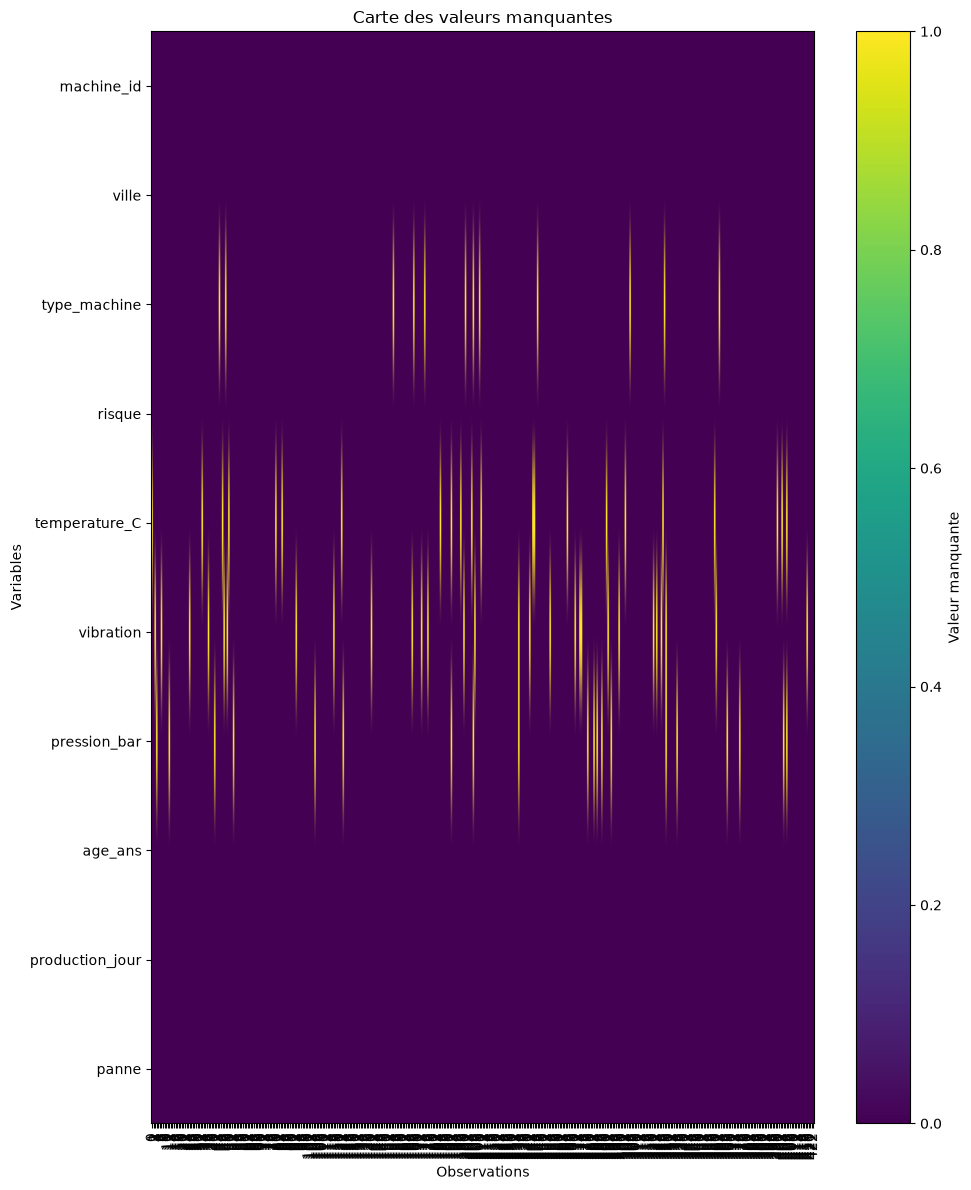

In [15]:
plt.figure(figsize=(10, 12))

plt.imshow(
    df.isna().T,
    aspect="auto",
    cmap="viridis"
)

plt.xticks(
    ticks=range(len(df)),
    labels=range(len(df)),
    rotation=90
)

plt.yticks(
    ticks=range(len(df.columns)),
    labels=df.columns
)

plt.xlabel("Observations")
plt.ylabel("Variables")
plt.title("Carte des valeurs manquantes")
plt.colorbar(label="Valeur manquante")

plt.tight_layout()
plt.show()

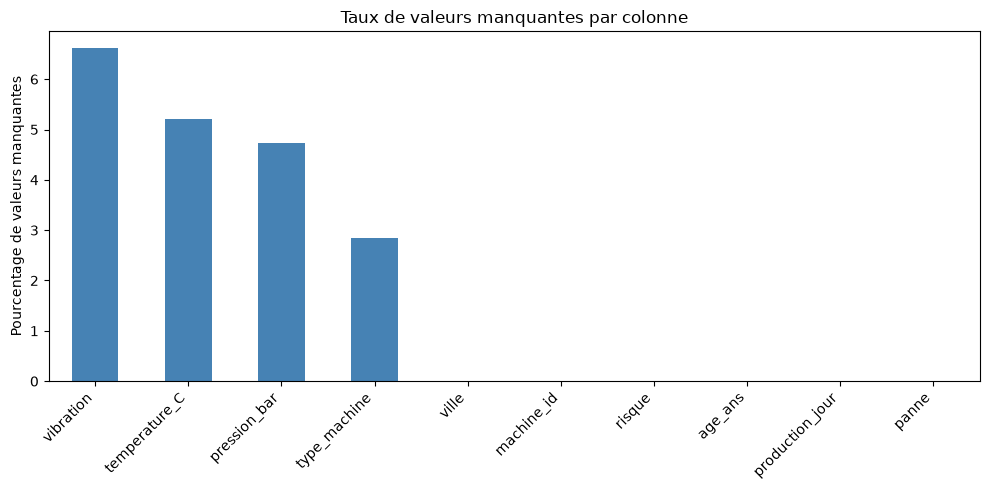

In [17]:
taux_na = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
taux_na.plot(kind="bar", color="steelblue")
plt.ylabel("Pourcentage de valeurs manquantes")
plt.title("Taux de valeurs manquantes par colonne")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## C. Nettoyage et imputation

In [18]:
# TODO : traiter doublons et valeurs manquantes.
# Justifier moyenne / médiane / mode / catégorie 'Inconnu' selon les cas.
clean_df = df.copy()

In [19]:
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

In [20]:
colonnes_categorielles = [
    "ville",
    "type_machine",
    "risque"
]

for colonne in colonnes_categorielles:
    clean_df[colonne] = clean_df[colonne].astype("string").str.strip()
    clean_df[colonne] = clean_df[colonne].fillna("Inconnu")


## D. Valeurs aberrantes

In [ ]:
# TODO 1 : boxplot
# TODO 2 : méthode IQR
# TODO 3 : Z-score
# TODO 4 : modified Z-score / MAD
# BONUS : Isolation Forest


### Challenge D
Créez un tableau comparatif :
`machine_id | IQR | Z-score | MAD | IsolationForest | décision métier`

Une détection n'est **pas** une suppression automatique.

In [ ]:
# TODO

## E. Encodage, normalisation, feature engineering

In [ ]:
# TODO :
# - OneHotEncoder pour variables nominales
# - StandardScaler pour numériques si pertinent
# - créer au moins 2 features utiles
# - éviter leakage


## F. EDA

In [ ]:
# TODO : produire au moins 4 graphiques :
# 1 histogramme
# 1 boxplot
# 1 barplot
# 1 scatterplot


### Conclusions attendues
- 5 constats factuels
- 2 hypothèses à tester au Jour 2
- 3 limites de la base


## G. Export pour le Jour 2

In [ ]:
# TODO :
# clean_df.to_csv("../data/data_J1_clean.csv", index=False)
